# Amazon Sales Dataset — Data Cleaning & Reporting Automation
**Data Analysis Internship Project**

This notebook automates an end-to-end pipeline on the Amazon Sales product dataset:
1. Load & understand the dataset
2. Assess data quality
3. Clean the data
4. Exploratory Data Analysis (EDA)
5. Visualization
6. Automation (reusable functions in `main.py`)
7. Automated Excel & PDF report generation
8. Final deliverables

All heavy-lifting functions live in `main.py` and `report_generator.py` so this notebook
just calls them stage by stage and displays the results.

In [1]:
import sys
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

from main import (
    load_data, data_quality_report, clean_data, analyze_data,
    create_visualizations, save_cleaned_dataset
)
from report_generator import generate_excel_report, generate_pdf_report

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100
print("Libraries and project functions loaded successfully.")

Libraries and project functions loaded successfully.


## Stage 1: Understand the Dataset

Load the raw CSV and get a first look at its shape, columns, and data types.

In [2]:
raw_df = load_data()
print(f"Rows: {raw_df.shape[0]}, Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 1465, Columns: 16


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [4]:
raw_df.describe(include='all').T

,count,unique,top,freq
product_id,1465,1351,B07JW9H4J1,3
product_name,1465,1337,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
category,1465,211,Computers&Accessories|Accessories&Peripherals|...,233
discounted_price,1465,550,₹199,53
actual_price,1465,449,₹999,120
discount_percentage,1465,92,50%,56
rating,1465,28,4.1,244
rating_count,1463,1143,"9,378",9
about_product,1465,1293,[CHARGE & SYNC FUNCTION]- This cable comes wit...,6
user_id,1465,1194,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...",10


## Stage 2: Data Quality Assessment

Check for missing values, duplicate rows, and columns that are stored as the wrong data type
(e.g. prices stored as text with ₹ and commas).

In [5]:
dq = data_quality_report(raw_df)

print(f"Duplicate rows: {dq['duplicate_rows']}")
print(f"Duplicate product IDs: {dq['duplicate_product_ids']}")
print("\nMissing values by column:")
for col, n in dq['missing_values'].items():
    print(f"  {col}: {n}")

print("\nSample of raw price/rating columns (note the text formatting issues):")
raw_df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].head()

Duplicate rows: 0
Duplicate product IDs: 114

Missing values by column:
  rating_count: 2

Sample of raw price/rating columns (note the text formatting issues):


,discounted_price,actual_price,discount_percentage,rating,rating_count
0,₹399,"₹1,099",64%,4.2,"24,269"
1,₹199,₹349,43%,4.0,"43,994"
2,₹199,"₹1,899",90%,3.9,"7,928"
3,₹329,₹699,53%,4.2,"94,363"
4,₹154,₹399,61%,4.2,"16,905"


**Issues identified:**
- `discounted_price` / `actual_price` contain `₹` symbols and comma thousands separators — stored as text, not numbers
- `discount_percentage` contains a trailing `%` — stored as text
- `rating_count` contains comma thousands separators — stored as text
- `rating` has at least one non-numeric / corrupted value
- 1 row is missing `rating_count`

## Stage 3: Data Cleaning

Apply the `clean_data()` function, which:
- Removes duplicate rows
- Trims whitespace from text columns
- Converts `discounted_price`, `actual_price` to numeric (strips ₹ and commas)
- Converts `discount_percentage` to numeric (strips %)
- Converts `rating` to numeric, dropping rows with invalid ratings
- Converts `rating_count` to numeric, filling missing values with 0
- Drops rows missing a product name or category
- Removes rows with impossible (non-positive) prices

In [6]:
clean_df = clean_data(raw_df)
print(f"Rows before cleaning: {len(raw_df)}")
print(f"Rows after cleaning:  {len(clean_df)}")
clean_df[['product_name', 'category', 'discounted_price', 'actual_price',
          'discount_percentage', 'rating', 'rating_count']].head()

Rows before cleaning: 1465
Rows after cleaning:  1464


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905


In [7]:
clean_df.dtypes

product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count             Int64
about_product              str
user_id                    str
user_name                  str
review_id                  str
review_title               str
review_content             str
img_link                   str
product_link               str
dtype: object

## Stage 4: Exploratory Data Analysis (EDA)

Compute key statistics: totals, averages, top categories, top-rated / most-reviewed /
most-expensive products.

In [8]:
stats, enriched_df = analyze_data(clean_df)

print(f"Total products (cleaned):     {stats['total_products']}")
print(f"Total categories:             {stats['total_categories']}")
print(f"Average rating:               {stats['average_rating']}")
print(f"Highest / lowest rating:      {stats['highest_rating']} / {stats['lowest_rating']}")
print(f"Average discount %:           {stats['average_discount_pct']}%")
print(f"Highest discount %:           {stats['highest_discount_pct']}%")
print(f"Average discounted price:     ₹{stats['average_discounted_price']}")
print(f"Average actual price:         ₹{stats['average_actual_price']}")

Total products (cleaned):     1464
Total categories:             9
Average rating:               4.1
Highest / lowest rating:      5.0 / 2.0
Average discount %:           47.71%
Highest discount %:           94.0%
Average discounted price:     ₹3126.01
Average actual price:         ₹5447.0


In [9]:
print("Top 10 Categories by number of products:")
display(stats['top_categories'])

Top 10 Categories by number of products:


main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

In [10]:
print("Top 5 Rated Products:")
display(stats['top_rated_products'])

Top 5 Rated Products:


,product_name,rating
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8
1201,"Oratech Coffee Frother electric, milk frother ...",4.8


In [11]:
print("Top 10 Most Reviewed Products:")
display(stats['most_reviewed_products'])

Top 10 Most Reviewed Products:


,product_name,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836
566,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",313832


In [12]:
print("Top 10 Most Expensive Products:")
display(stats['most_expensive_products'])

Top 10 Most Expensive Products:


,product_name,actual_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,139900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,85000.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,79990.0
1353,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,75990.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",74999.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,70900.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,69999.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,69999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,69900.0
108,VU 139 cm (55 inches) The GloLED Series 4K Sma...,65000.0


## Stage 5: Visualization

Generate all 8 charts and save them to the `charts/` folder.

In [13]:
chart_paths = create_visualizations(enriched_df, stats)
print(f"Saved {len(chart_paths)} charts:")
for p in chart_paths:
    print(f"  {p}")

Saved 8 charts:
  charts/category_chart.png
  charts/rating_chart.png
  charts/top_products.png
  charts/discount_chart.png
  charts/avg_price_by_category.png
  charts/top_rated_categories.png
  charts/price_scatter.png
  charts/expensive_products.png


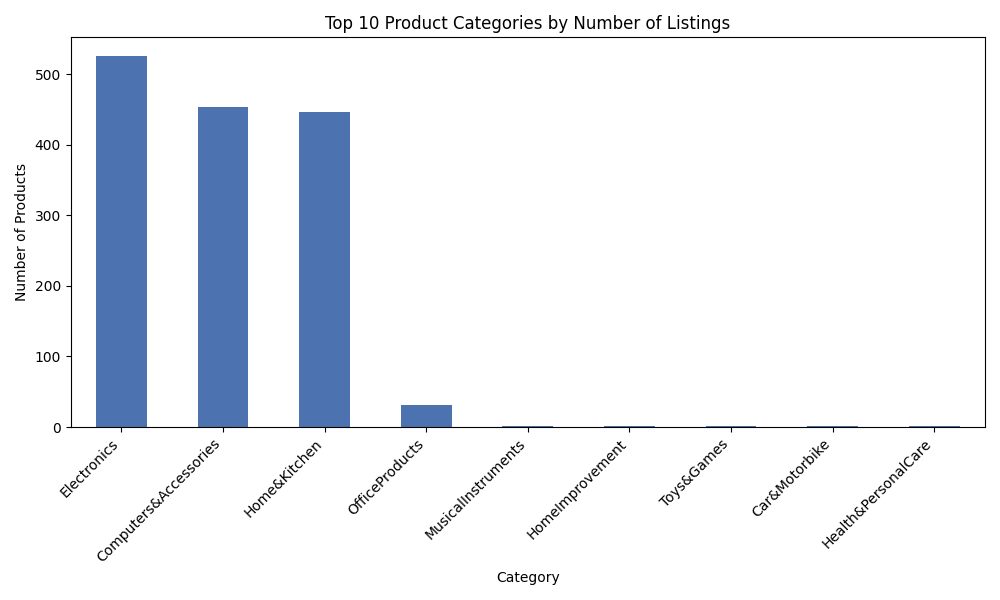

In [14]:
display(Image(filename='charts/category_chart.png'))

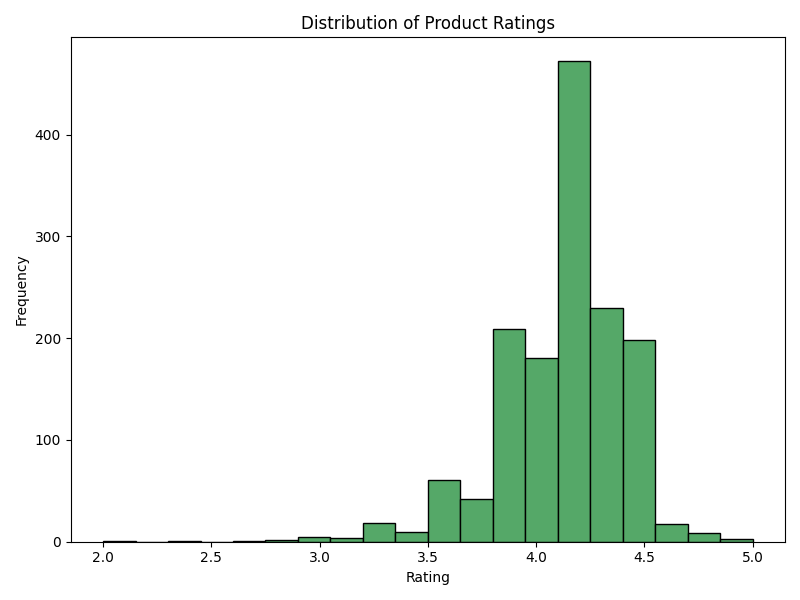

In [15]:
display(Image(filename='charts/rating_chart.png'))

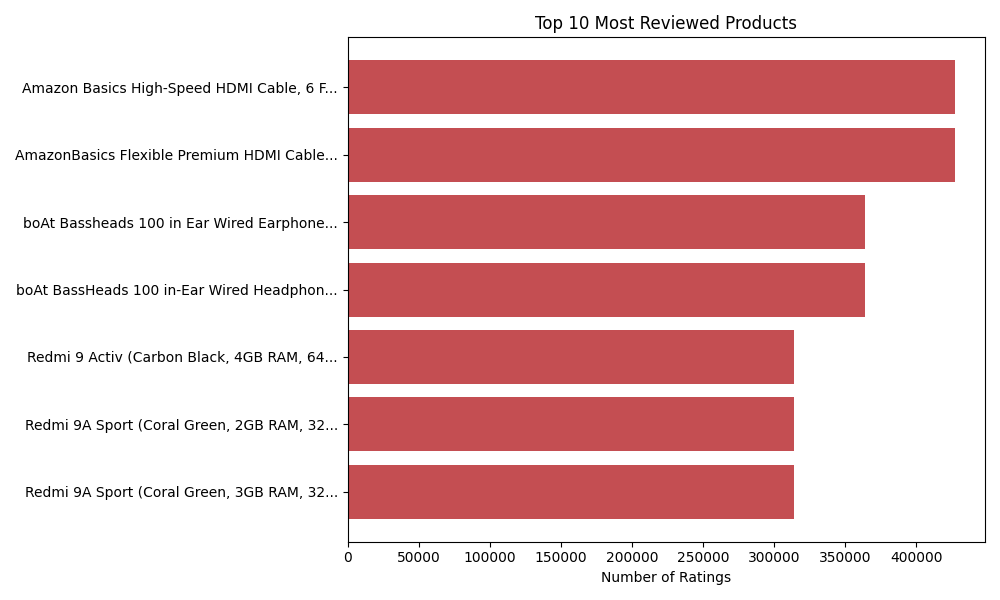

In [16]:
display(Image(filename='charts/top_products.png'))

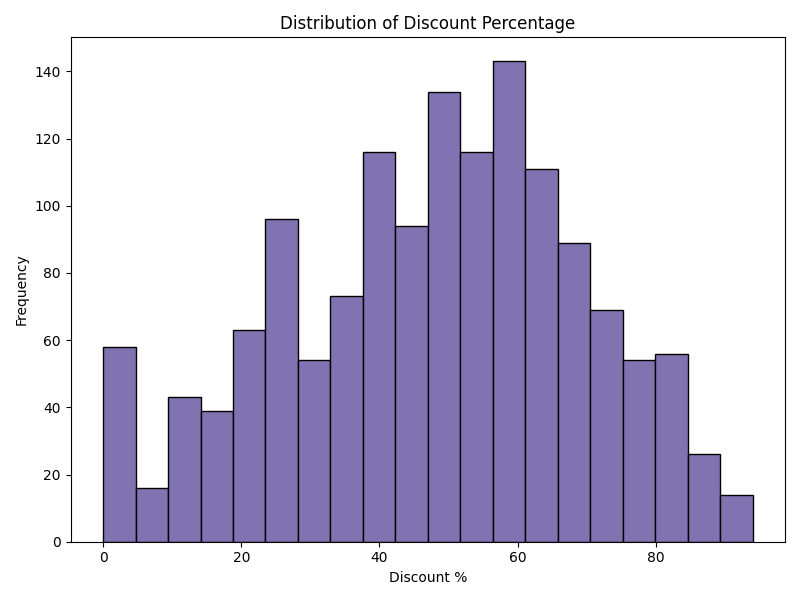

In [17]:
display(Image(filename='charts/discount_chart.png'))

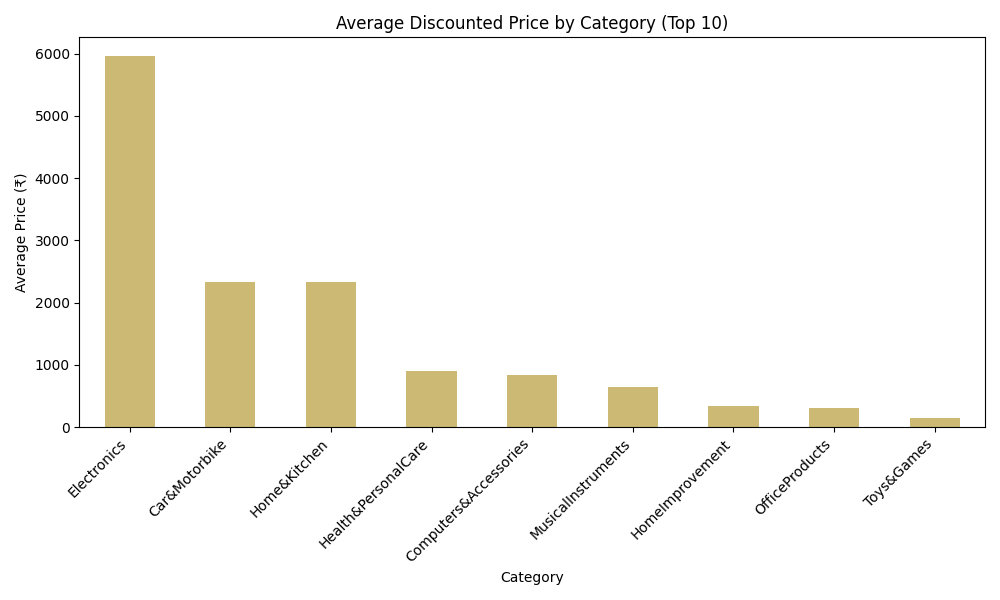

In [18]:
display(Image(filename='charts/avg_price_by_category.png'))

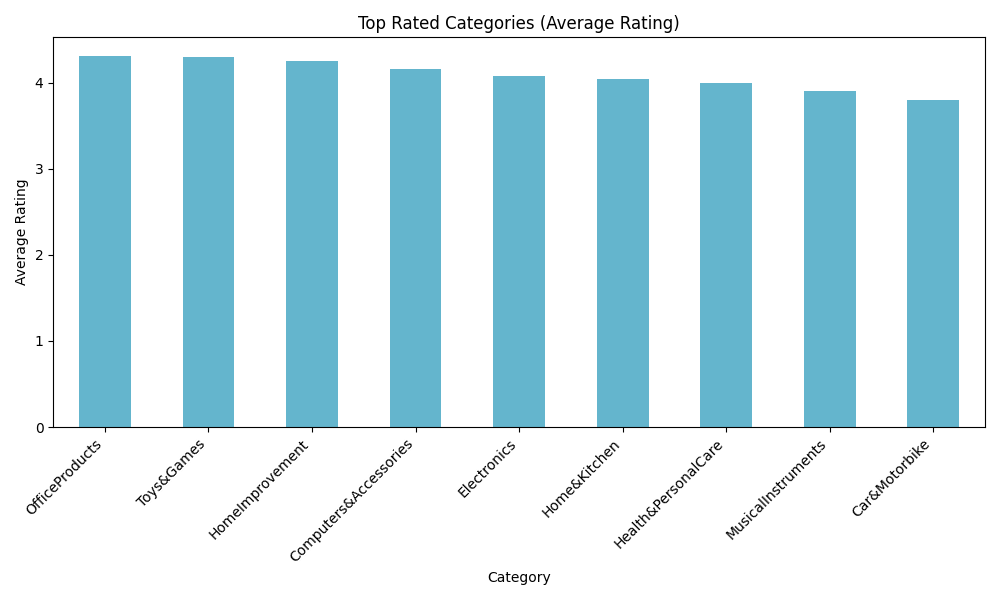

In [19]:
display(Image(filename='charts/top_rated_categories.png'))

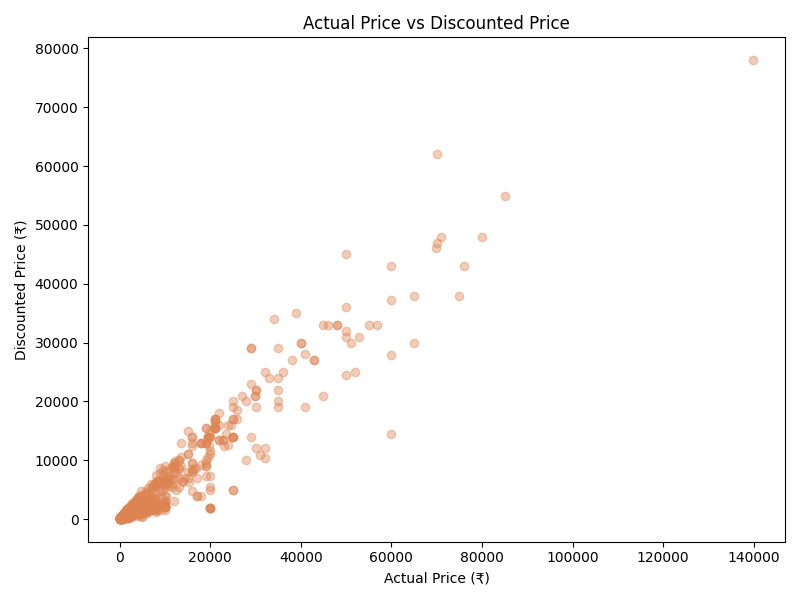

In [20]:
display(Image(filename='charts/price_scatter.png'))

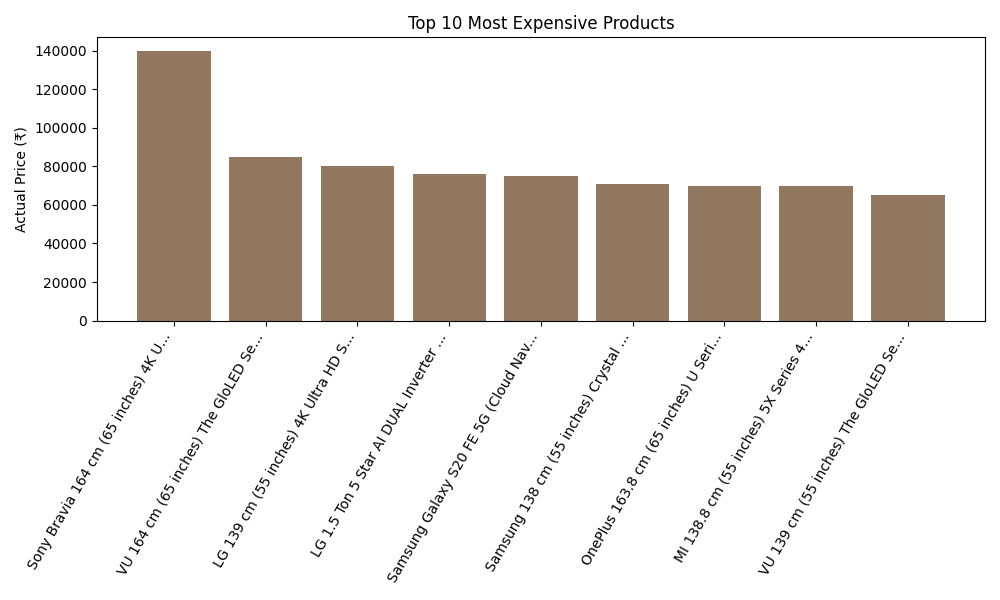

In [21]:
display(Image(filename='charts/expensive_products.png'))

## Stage 6: Automation

All the steps above (`load_data`, `clean_data`, `analyze_data`, `create_visualizations`,
`save_cleaned_dataset`, `generate_excel_report`, `generate_pdf_report`) are reusable
functions defined in `main.py` / `report_generator.py`.

Running `python main.py` from the terminal re-executes the **entire pipeline** end-to-end —
from raw CSV to cleaned data, charts, and reports — with a single command.

In [22]:
cleaned_path = save_cleaned_dataset(clean_df)
print(f"Cleaned dataset saved to: {cleaned_path}")

Cleaned dataset saved to: cleaned_data/cleaned_amazon_sales.csv


## Stage 7: Automated Report Generation

Generate the Excel report (Summary, Cleaned Data, Category Stats, Top Products sheets)
and the PDF report (title page, dataset summary, key findings, charts, conclusion).

In [23]:
excel_path = generate_excel_report(clean_df, stats, dq)
pdf_path = generate_pdf_report(stats, dq, chart_paths)
print(f"Excel report saved to: {excel_path}")
print(f"PDF report saved to:   {pdf_path}")

Excel report saved to: reports/report.xlsx
PDF report saved to:   reports/report.pdf


## Stage 8: Final Deliverables

```
Amazon-Sales-Automation/
├── data/amazon.csv                        # Raw dataset
├── cleaned_data/cleaned_amazon_sales.csv  # Cleaned dataset
├── charts/*.png                           # 8 visualizations
├── reports/report.xlsx                    # Automated Excel report
├── reports/report.pdf                     # Automated PDF report
├── notebook.ipynb                         # This notebook
├── main.py                                # Core pipeline functions
├── report_generator.py                    # Report generation functions
└── requirements.txt
```

**Summary of what this project demonstrates:**
- ✔ Data Cleaning (duplicates, missing values, currency/percent parsing, invalid rows)
- ✔ Exploratory Data Analysis
- ✔ Data Visualization (8 charts)
- ✔ Python Automation (single-command pipeline via `main.py`)
- ✔ Automated Excel Reporting
- ✔ Automated PDF Reporting

In [24]:
# Quick final check that every deliverable exists on disk
import os
for path in [
    'data/amazon.csv',
    'cleaned_data/cleaned_amazon_sales.csv',
    'reports/report.xlsx',
    'reports/report.pdf',
] + chart_paths:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"[{status}] {path}")

[OK] data/amazon.csv
[OK] cleaned_data/cleaned_amazon_sales.csv
[OK] reports/report.xlsx
[OK] reports/report.pdf
[OK] charts/category_chart.png
[OK] charts/rating_chart.png
[OK] charts/top_products.png
[OK] charts/discount_chart.png
[OK] charts/avg_price_by_category.png
[OK] charts/top_rated_categories.png
[OK] charts/price_scatter.png
[OK] charts/expensive_products.png
